# 🎨 Task 1 — Step 2: Color Bias & Chromatic Invariance

## 1. Overview & Theoretical Motivation
In this notebook, we examine the extent to which each vision model relies on **chromatic information** (color) as a predictive cue versus **geometric/structural evidence** (shape, edges, contours).

Standard natural image classifiers can easily exploit color shortcuts (e.g., associating green with frogs, blue with airplanes/ships, or orange with cats/foxes). Under distribution shift or adversarial settings, such shortcuts fail.

### Interventions Tested
1. **Grayscale**: Removes chromatic information entirely while preserving luminance and spatial geometry:
   $$I_{\text{gray}} = 0.2989 R + 0.5870 G + 0.1140 B$$
   Expanded across 3 identical channels to match model input dimensions.
2. **Fixed Hue Rotation (+90°)**: Shifts the color palette cyclically around the HSV color circle by $+90^\circ$ ($+0.25$ in normalized hue space).
   - Preserves luminance (contrast) and saturation.
   - Completely disrupts natural color associations (e.g. grass becomes magenta, sky becomes yellowish).

### Hypotheses
- **ResNet-50**: Convolutional networks trained with standard cross-entropy frequently rely on color and low-level texture statistics. We hypothesize a moderate to high drop in accuracy and lower prediction consistency under hue shift.
- **ViT-B/16**: Patch self-attention allows global contextual integration. While still sensitive to color, global shape cues may partially insulate predictions.
- **CLIP (Head & Zero-Shot)**: Trained on diverse web images paired with natural language captions, CLIP models often develop semantic invariances. We expect CLIP to maintain higher prediction consistency under chromatic interventions.


In [1]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import f1_score, confusion_matrix
from tqdm.auto import tqdm

from shared.src.seed import set_seed, SEED
set_seed(6304)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} | Seed: {SEED}")


Using device: cuda | Seed: 6304


## 2. Load Evaluation Subset, Clean Baseline Predictions & Models


In [2]:
from task1_inductive_biases.src.data import load_stl10, STL10_CLASSES
from task1_inductive_biases.src.backbones import (
    ResNet50Backbone, ViTB16Backbone, CLIPBackbone, LinearHead,
    RESNET_NORM, VIT_NORM, CLIP_NORM
)

# Load test dataset and cached evaluation indices
_, test_ds, class_names = load_stl10(root='../../data/stl10')
eval_indices = np.load('../cache/eval_indices.npy')
eval_labels  = np.load('../cache/eval_labels.npy')
eval_sub     = Subset(test_ds, eval_indices.tolist())

print(f"Loaded evaluation subset: {len(eval_sub)} images")
print(f"Classes: {class_names}")

# Load backbones and trained linear classifier heads
backbones = {
    'ResNet-50': ResNet50Backbone().to(device),
    'ViT-B/16':  ViTB16Backbone().to(device),
    'CLIP':      CLIPBackbone().to(device),
}
norms = {'ResNet-50': RESNET_NORM, 'ViT-B/16': VIT_NORM, 'CLIP': CLIP_NORM}

heads = {}
for name, bb in backbones.items():
    safe = name.replace('/', '_').replace(' ', '_')
    head = LinearHead(bb.dim, 10).to(device)
    head.load_state_dict(torch.load(f'../cache/head_{safe}.pth', map_location=device))
    head.eval()
    heads[name] = head

# Load clean baseline predictions
clean_preds = {
    'ResNet-50': np.load('../cache/clean_preds_ResNet-50.npy'),
    'ViT-B/16':  np.load('../cache/clean_preds_ViT-B_16.npy'),
    'CLIP':      np.load('../cache/clean_preds_CLIP.npy'),
    'CLIP-ZS':   np.load('../cache/clean_preds_CLIP-ZS.npy'),
}

print("✅ Backbones, heads, and clean baseline predictions successfully loaded!")


Loading fast pre-cached STL-10:
  Train: ..\..\data\stl10_train_fast.pt
  Test:  ..\..\data\stl10_test_fast.pt
Loaded evaluation subset: 500 images
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ Backbones, heads, and clean baseline predictions successfully loaded!


C:\Users\moize\AppData\Local\Temp\ipykernel_33692\399414670.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  head.load_state_dict(torch.load(f'../cache/head_{safe}.pth',

## 3. Apply Color Transformations (Grayscale & Hue +90°)
We apply transformations to all 500 images in the evaluation subset **prior** to model normalization.


In [3]:
from task1_inductive_biases.src.transforms import to_grayscale, hue_rotation

print("Generating color-transformed images for evaluation subset...")
gray_images = []
hue_images  = []

for i in tqdm(range(len(eval_sub)), desc="Applying Color Transforms"):
    img_tensor, _ = eval_sub[i]  # (3, 224, 224) in [0, 1]
    gray_images.append(to_grayscale(img_tensor))
    hue_images.append(hue_rotation(img_tensor, degrees=90.0))

print(f"✅ Generated {len(gray_images)} grayscale images and {len(hue_images)} hue-rotated images")


Generating color-transformed images for evaluation subset...


Applying Color Transforms:   0%|          | 0/500 [00:00<?, ?it/s]

✅ Generated 500 grayscale images and 500 hue-rotated images


## 4. Visual Gallery of Transformations
We visually inspect Original, Grayscale, and Hue-Rotated images across multiple classes.


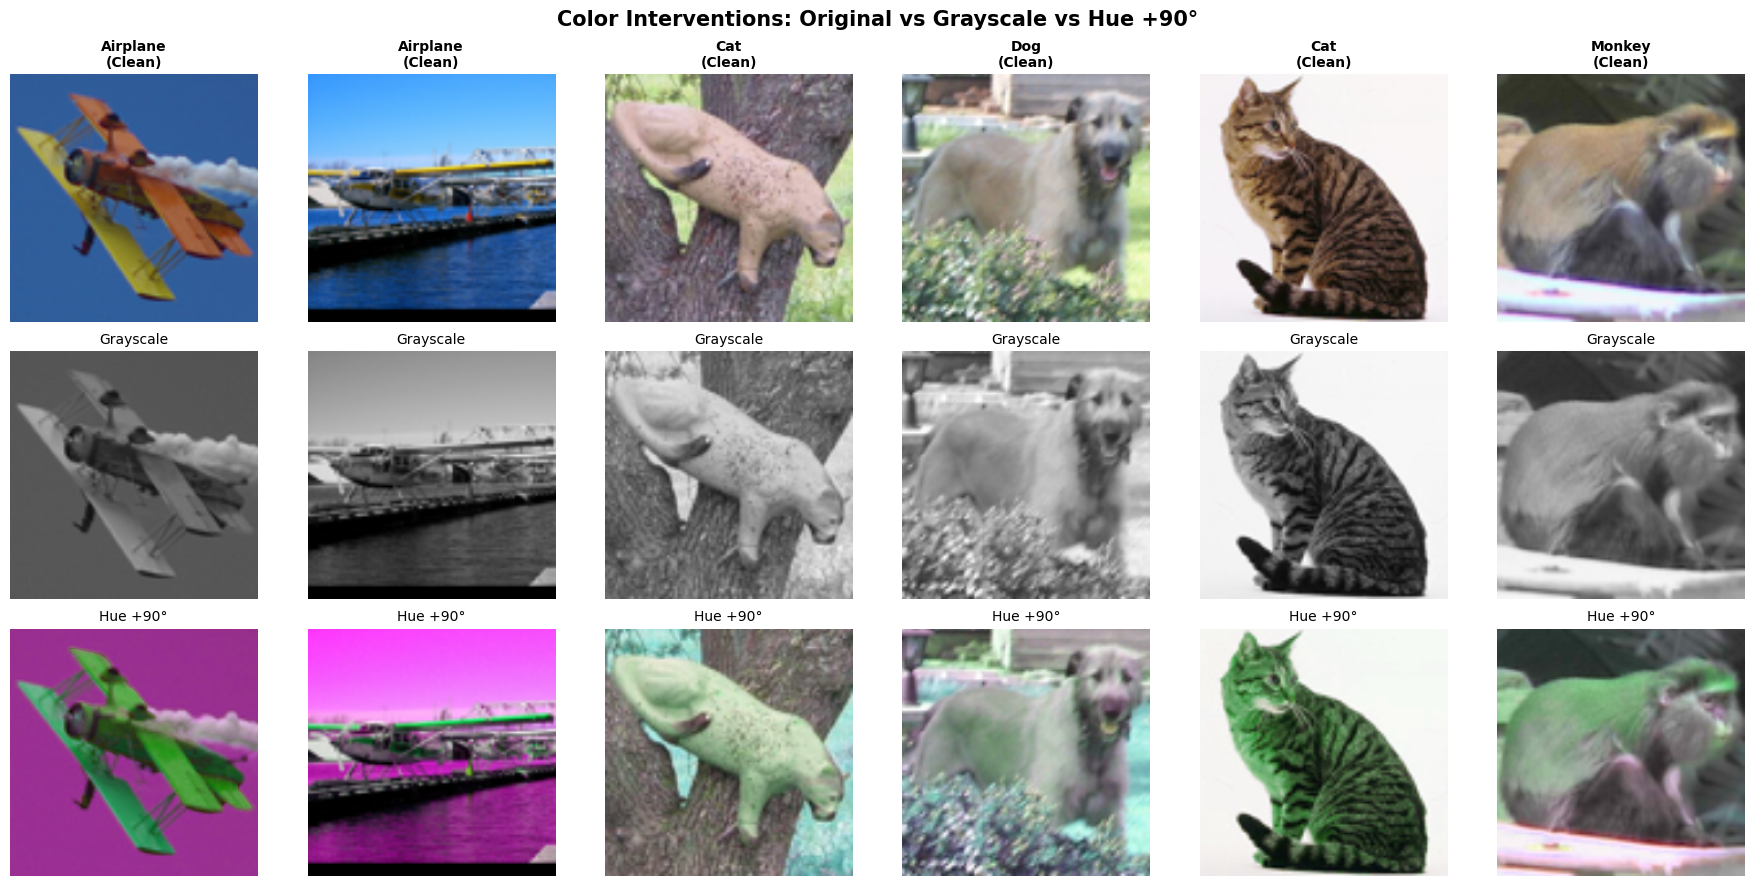

In [4]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("Color Interventions: Original vs Grayscale vs Hue +90°", fontsize=15, fontweight='bold')
sample_indices = [0, 50, 100, 150, 200, 250]

for col_idx, img_idx in enumerate(sample_indices):
    orig, lbl = eval_sub[img_idx]
    gray = gray_images[img_idx]
    hue  = hue_images[img_idx]

    axes[0, col_idx].imshow(orig.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, col_idx].set_title(f"{class_names[lbl].capitalize()}\n(Clean)", fontsize=10, fontweight='bold')

    axes[1, col_idx].imshow(gray.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, col_idx].set_title("Grayscale", fontsize=10)

    axes[2, col_idx].imshow(hue.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[2, col_idx].set_title("Hue +90°", fontsize=10)

for ax in axes.flat:
    ax.axis('off')

axes[0, 0].set_ylabel("Clean Original", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Grayscale", fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel("Hue +90°", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/color_transforms_samples.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Channel Distribution / Histogram Analysis
To mathematically prove that geometry is preserved while color distributions are altered, we plot channel pixel intensity distributions for a sample image across conditions.


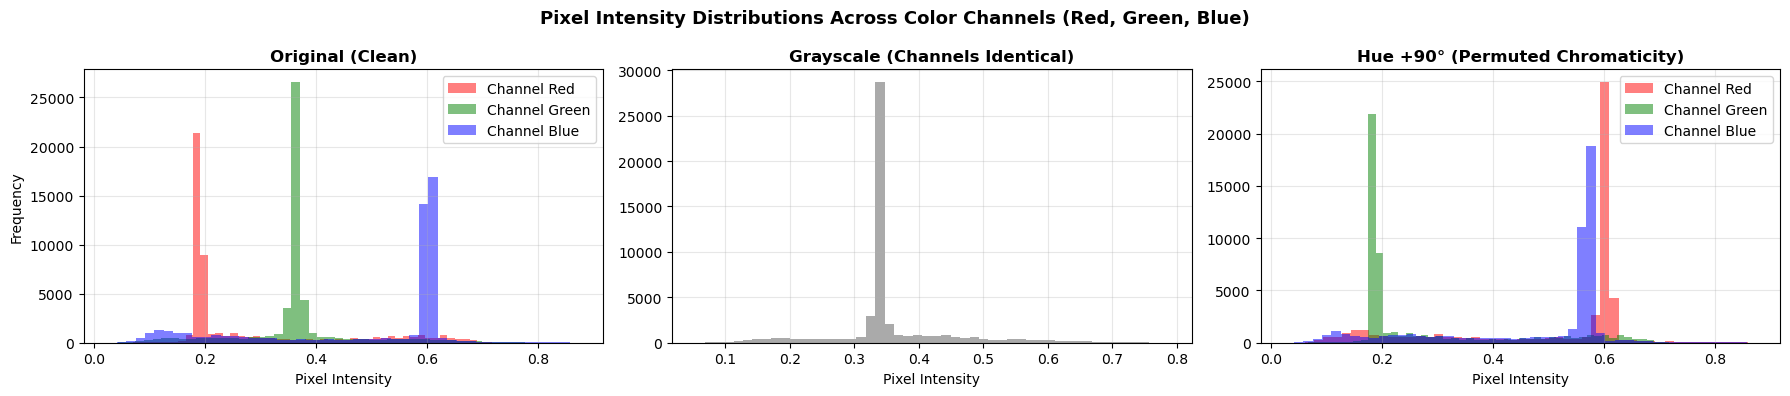

In [5]:
sample_orig, _ = eval_sub[0]
sample_gray = gray_images[0]
sample_hue  = hue_images[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Pixel Intensity Distributions Across Color Channels (Red, Green, Blue)", fontsize=13, fontweight='bold')
colors = ['red', 'green', 'blue']

for ch, col in enumerate(colors):
    axes[0].hist(sample_orig[ch].flatten().numpy(), bins=50, color=col, alpha=0.5, label=f'Channel {col.capitalize()}')
axes[0].set_title("Original (Clean)", fontweight='bold')
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for ch, col in enumerate(colors):
    axes[1].hist(sample_gray[ch].flatten().numpy(), bins=50, color='gray', alpha=0.3, label=f'Ch {ch}')
axes[1].set_title("Grayscale (Channels Identical)", fontweight='bold')
axes[1].set_xlabel("Pixel Intensity")
axes[1].grid(True, alpha=0.3)

for ch, col in enumerate(colors):
    axes[2].hist(sample_hue[ch].flatten().numpy(), bins=50, color=col, alpha=0.5, label=f'Channel {col.capitalize()}')
axes[2].set_title("Hue +90° (Permuted Chromaticity)", fontweight='bold')
axes[2].set_xlabel("Pixel Intensity")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/color_histogram_analysis.png', dpi=200, bbox_inches='tight')
plt.show()


## 6. Evaluate Models on Color-Transformed Images
We evaluate all 4 models:
- ResNet-50 (Head)
- ViT-B/16 (Head)
- CLIP (Head)
- CLIP (Zero-Shot)

We compute:
- Transformed Accuracy
- $\Delta$ Accuracy ($= \text{Acc}_{\text{trans}} - \text{Acc}_{\text{clean}}$)
- **Prediction Consistency**:
  $$\text{Consistency} = \frac{1}{N} \sum_{i=1}^N \mathbf{1}[\hat{y}(x_i) == \hat{y}(T(x_i))]$$


In [6]:
def predict_transformed_batch(backbone, norm, head, image_list, batch_size=64):
    """Predict classes and confidences for a list of image tensors."""
    all_preds, all_confs = [], []
    backbone.eval()
    if head is not None:
        head.eval()

    for i in range(0, len(image_list), batch_size):
        batch = torch.stack(image_list[i:i+batch_size])
        batch = torch.stack([norm(img) for img in batch]).to(device)
        with torch.no_grad():
            feats = backbone(batch)
            logits = head(feats)
            probs = F.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)
            all_preds.append(preds.cpu())
            all_confs.append(confs.cpu())

    return torch.cat(all_preds).numpy(), torch.cat(all_confs).numpy()


def predict_clip_zeroshot_transformed(clip_backbone, norm, image_list, class_names, batch_size=64):
    """Zero-shot prediction for a list of transformed images."""
    prompts = [f"a photo of a {c}." for c in class_names]
    text_feats = clip_backbone.encode_text(prompts)
    all_preds, all_confs = [], []

    clip_backbone.eval()
    for i in range(0, len(image_list), batch_size):
        batch = torch.stack(image_list[i:i+batch_size])
        batch = torch.stack([norm(img) for img in batch]).to(device)
        with torch.no_grad():
            img_feats = clip_backbone(batch)
            sim = (img_feats @ text_feats.T) * 100.0
            probs = F.softmax(sim, dim=1)
            confs, preds = probs.max(dim=1)
            all_preds.append(preds.cpu())
            all_confs.append(confs.cpu())

    return torch.cat(all_preds).numpy(), torch.cat(all_confs).numpy()

# Run evaluations across Grayscale and Hue
color_results = {}
gray_predictions, hue_predictions = {}, {}

for name in ['ResNet-50', 'ViT-B/16', 'CLIP']:
    clean_acc = np.mean(clean_preds[name] == eval_labels)
    # Grayscale
    g_preds, _ = predict_transformed_batch(backbones[name], norms[name], heads[name], gray_images)
    g_acc = np.mean(g_preds == eval_labels)
    g_cons = np.mean(clean_preds[name] == g_preds)
    gray_predictions[name] = g_preds

    # Hue
    h_preds, _ = predict_transformed_batch(backbones[name], norms[name], heads[name], hue_images)
    h_acc = np.mean(h_preds == eval_labels)
    h_cons = np.mean(clean_preds[name] == h_preds)
    hue_predictions[name] = h_preds

    color_results[f"{name} (Head)"] = {
        'Clean Acc': clean_acc,
        'Gray Acc': g_acc, 'Gray Δ': g_acc - clean_acc, 'Gray Consistency': g_cons,
        'Hue Acc': h_acc,   'Hue Δ': h_acc - clean_acc,   'Hue Consistency': h_cons
    }

# CLIP Zero-Shot
clean_acc_zs = np.mean(clean_preds['CLIP-ZS'] == eval_labels)
g_preds_zs, _ = predict_clip_zeroshot_transformed(backbones['CLIP'], norms['CLIP'], gray_images, class_names)
g_acc_zs = np.mean(g_preds_zs == eval_labels)
g_cons_zs = np.mean(clean_preds['CLIP-ZS'] == g_preds_zs)
gray_predictions['CLIP-ZS'] = g_preds_zs

h_preds_zs, _ = predict_clip_zeroshot_transformed(backbones['CLIP'], norms['CLIP'], hue_images, class_names)
h_acc_zs = np.mean(h_preds_zs == eval_labels)
h_cons_zs = np.mean(clean_preds['CLIP-ZS'] == h_preds_zs)
hue_predictions['CLIP-ZS'] = h_preds_zs

color_results['CLIP (Zero-Shot)'] = {
    'Clean Acc': clean_acc_zs,
    'Gray Acc': g_acc_zs, 'Gray Δ': g_acc_zs - clean_acc_zs, 'Gray Consistency': g_cons_zs,
    'Hue Acc': h_acc_zs,   'Hue Δ': h_acc_zs - clean_acc_zs,   'Hue Consistency': h_cons_zs
}

df_color = pd.DataFrame(color_results).T
print("\n" + "="*85)
print("                       COLOR BIAS EVALUATION SUMMARY")
print("="*85)
print(df_color.to_string(float_format=lambda x: f"{x:+.4f}" if "Δ" in str(x) else f"{x:.4f}"))
print("="*85)



                       COLOR BIAS EVALUATION SUMMARY
                  Clean Acc  Gray Acc  Gray Δ  Gray Consistency  Hue Acc   Hue Δ  Hue Consistency
ResNet-50 (Head)     0.9700    0.9400 -0.0300            0.9600   0.9440 -0.0260           0.9600
ViT-B/16 (Head)      0.9720    0.9460 -0.0260            0.9700   0.9440 -0.0280           0.9560
CLIP (Head)          0.9680    0.9280 -0.0400            0.9360   0.9360 -0.0320           0.9500
CLIP (Zero-Shot)     0.9340    0.8960 -0.0380            0.9260   0.9040 -0.0300           0.9120


## 7. Comparative Charts: Accuracy Drop & Prediction Consistency
We plot:
1. Accuracy across Clean, Grayscale, and Hue +90°
2. Accuracy drop $\Delta$ from clean baseline
3. Prediction consistency with clean predictions


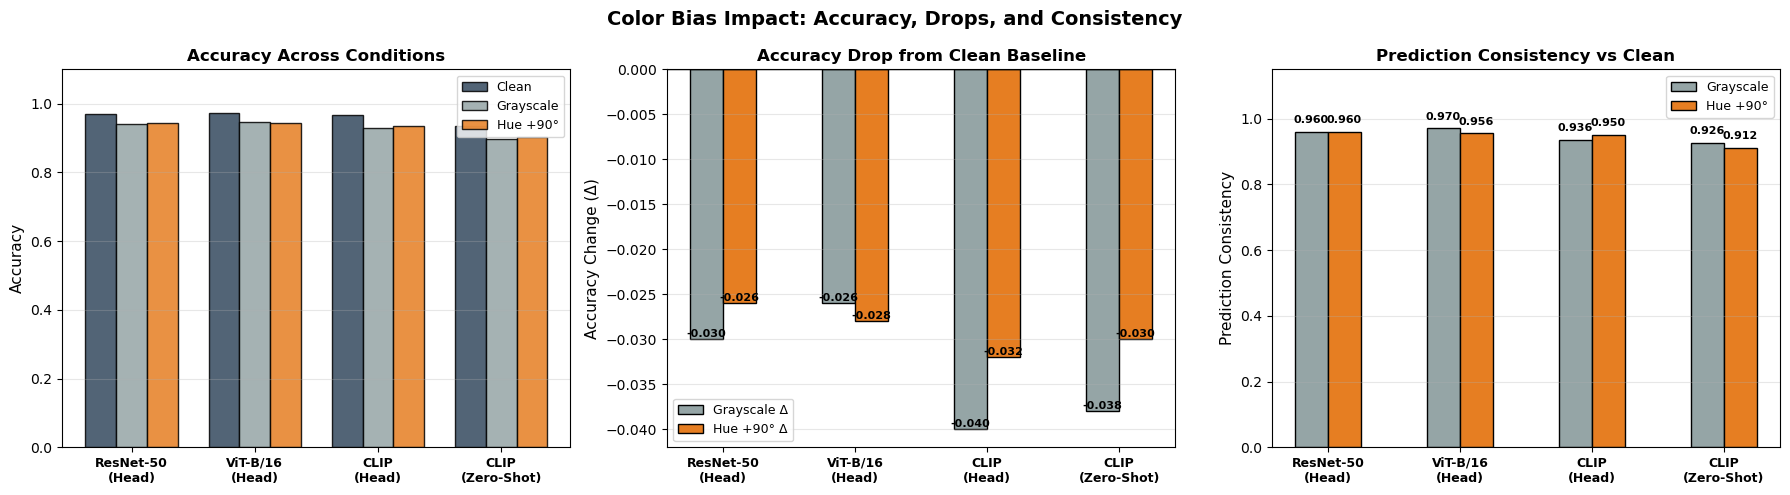

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Color Bias Impact: Accuracy, Drops, and Consistency", fontsize=14, fontweight='bold')
model_labels = [m.replace(' ', '\n') for m in color_results.keys()]
x = np.arange(len(model_labels))
width = 0.25

# Panel 1: Accuracy comparison
ax = axes[0]
c_accs = df_color['Clean Acc'].values
g_accs = df_color['Gray Acc'].values
h_accs = df_color['Hue Acc'].values
ax.bar(x - width, c_accs, width, label='Clean', color='#34495e', alpha=0.85, edgecolor='black')
ax.bar(x,         g_accs, width, label='Grayscale', color='#95a5a6', alpha=0.85, edgecolor='black')
ax.bar(x + width, h_accs, width, label='Hue +90°', color='#e67e22', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=9, fontweight='bold')
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Accuracy Across Conditions", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Accuracy Drop Δ
ax = axes[1]
g_deltas = df_color['Gray Δ'].values
h_deltas = df_color['Hue Δ'].values
b1 = ax.bar(x - width/2, g_deltas, width, label='Grayscale Δ', color='#95a5a6', edgecolor='black')
b2 = ax.bar(x + width/2, h_deltas, width, label='Hue +90° Δ', color='#e67e22', edgecolor='black')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=9, fontweight='bold')
ax.set_ylabel("Accuracy Change (Δ)", fontsize=11)
ax.set_title("Accuracy Drop from Clean Baseline", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar in b1 + b2:
    val = bar.get_height()
    va = 'bottom' if val < 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:+.3f}", ha='center', va=va, fontsize=8, fontweight='bold')

# Panel 3: Prediction Consistency
ax = axes[2]
g_cons = df_color['Gray Consistency'].values
h_cons = df_color['Hue Consistency'].values
b3 = ax.bar(x - width/2, g_cons, width, label='Grayscale', color='#95a5a6', edgecolor='black')
b4 = ax.bar(x + width/2, h_cons, width, label='Hue +90°', color='#e67e22', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=9, fontweight='bold')
ax.set_ylabel("Prediction Consistency", fontsize=11)
ax.set_title("Prediction Consistency vs Clean", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar in b3 + b4:
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/color_bias_charts.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. Per-Class Prediction Consistency Heatmap
We examine which classes suffer the steepest loss in prediction consistency when color is altered.


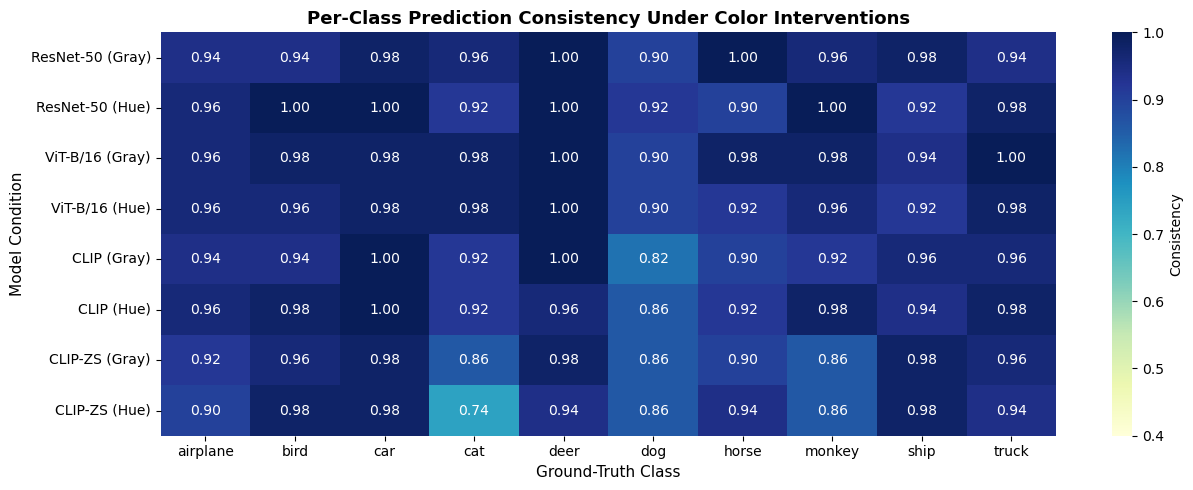

In [8]:
class_consistency = {}
for mkey in ['ResNet-50', 'ViT-B/16', 'CLIP', 'CLIP-ZS']:
    c_p = clean_preds[mkey]
    g_p = gray_predictions[mkey]
    h_p = hue_predictions[mkey]
    
    g_class_cons = [np.mean((c_p == g_p)[eval_labels == c]) for c in range(10)]
    h_class_cons = [np.mean((c_p == h_p)[eval_labels == c]) for c in range(10)]
    class_consistency[f"{mkey} (Gray)"] = g_class_cons
    class_consistency[f"{mkey} (Hue)"]  = h_class_cons

df_class_cons = pd.DataFrame(class_consistency, index=class_names).T

plt.figure(figsize=(13, 5))
sns.heatmap(df_class_cons, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0.4, vmax=1.0, cbar_kws={'label': 'Consistency'})
plt.title("Per-Class Prediction Consistency Under Color Interventions", fontsize=13, fontweight='bold')
plt.xlabel("Ground-Truth Class", fontsize=11)
plt.ylabel("Model Condition", fontsize=11)
plt.tight_layout()
plt.savefig('../results/color_per_class_consistency.png', dpi=200, bbox_inches='tight')
plt.show()


## 9. Failure & Prediction Transition Gallery
We inspect 6 cases where clean inputs were correctly predicted, but flipped upon color shift.


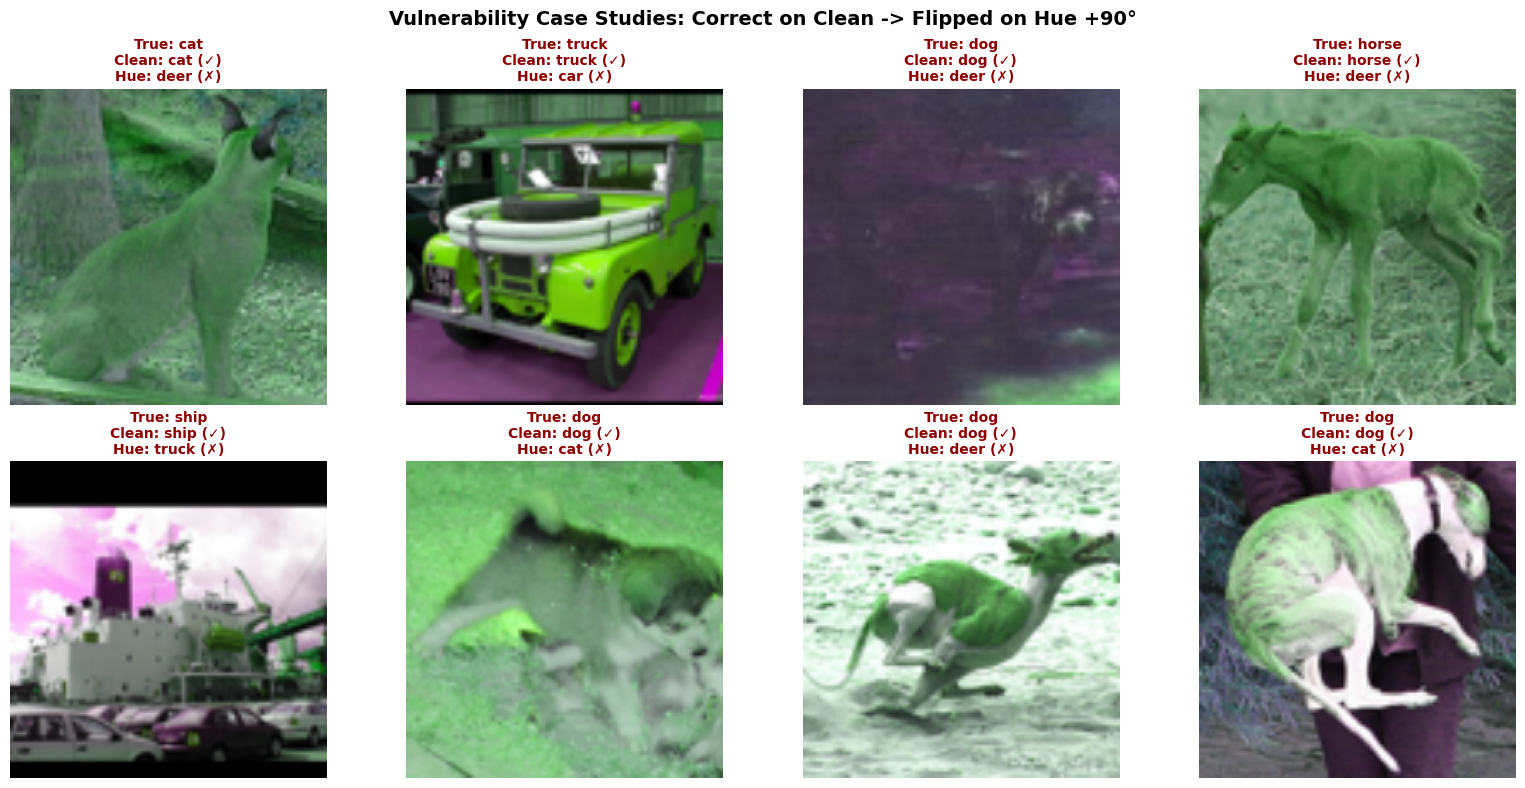

In [9]:
# Find images where ResNet was correct clean but failed on Hue
rn_clean_correct = (clean_preds['ResNet-50'] == eval_labels)
rn_hue_wrong     = (hue_predictions['ResNet-50'] != eval_labels)
fail_indices     = np.where(rn_clean_correct & rn_hue_wrong)[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Vulnerability Case Studies: Correct on Clean -> Flipped on Hue +90°", fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(fail_indices):
        img_idx = fail_indices[idx]
        orig_img, true_lbl = eval_sub[img_idx]
        hue_img = hue_images[img_idx]
        
        c_pred = clean_preds['ResNet-50'][img_idx]
        h_pred = hue_predictions['ResNet-50'][img_idx]
        
        ax.imshow(hue_img.permute(1, 2, 0).clamp(0, 1).numpy())
        ax.set_title(f"True: {class_names[true_lbl]}\nClean: {class_names[c_pred]} (✓)\nHue: {class_names[h_pred]} (✗)",
                     fontsize=10, fontweight='bold', color='darkred')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/color_failure_cases.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. Cache Transformed Images & Results
We save the transformed images and predictions for downstream representation analysis in Notebook 5.


In [10]:
# Save transformed images
torch.save(gray_images, '../cache/gray_images.pt')
torch.save(hue_images,  '../cache/hue_images.pt')

# Save transformed predictions
for mkey, preds in gray_predictions.items():
    safe = mkey.replace('/', '_').replace(' ', '_')
    np.save(f'../cache/gray_preds_{safe}.npy', preds)

for mkey, preds in hue_predictions.items():
    safe = mkey.replace('/', '_').replace(' ', '_')
    np.save(f'../cache/hue_preds_{safe}.npy', preds)

df_color.to_csv('../results/color_bias.csv')
print("✅ Color-transformed images and evaluation predictions successfully cached!")


✅ Color-transformed images and evaluation predictions successfully cached!
